In [1]:
!pip install fitparse

import fitparse
import pandas as pd
import glob

# Grab all .fit files in the upload directory
fit_files = glob.glob("*.fit")

def parse_fit(file_path):
    fitfile = fitparse.FitFile(file_path)
    records = []
    for record in fitfile.get_messages("record"):
        row = {}
        for data in record:
            if data.name in ['timestamp', 'heart_rate', 'enhanced_speed']:
                row[data.name] = data.value
        if 'heart_rate' in row and row['heart_rate'] is not None:
            records.append(row)
    df = pd.DataFrame(records)
    df['file'] = file_path
    return df

# Process both files
all_dfs = [parse_fit(f) for f in fit_files]
df_master = pd.concat(all_dfs, ignore_index=True)

print(f"Loaded {len(fit_files)} files successfully!")
print(df_master.head())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.7/65.7 kB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for fitparse: filename=fitparse-1.2.0-py3-none-any.whl size=68276 sha256=1ed6723d29e91bf1578cd52ee5ba963fb24a97c6c28468b9a479ee5391ff6b65
  Stored in directory: /root/.cache/pip/wheels/6a/8a/17/d5e85db99c2efece41b1aa8388d9e5c42d1796021b30f3f1ee
Successfully built fitparse
Loaded 2 files successfully!
   enhanced_speed  heart_rate           timestamp                    file
0             0.0         110 2026-06-01 13:47:12  477902121082061300.fit
1             0.0         110 2026-06-01 13:47:13  477902121082061300.fit
2             0.0         110 2026-06-01 13:47:14  477902121082061300.fit
3             0.0         110 2026-06-01 13:47:15  477902121082061300.fit
4             0.0         110 2026-06-01 13:47:16  477902121082061300.fit


In [2]:
# 1. Filter out stationary seconds (where speed is 0)
df_running = df_master[df_master['enhanced_speed'] > 0].copy()

# 2. Convert Speed (m/s) to Pace (min/km)
# Formula: 1000 meters / (speed * 60 seconds)
df_running['pace_min_km'] = 1000 / (df_running['enhanced_speed'] * 60)

# 3. Filter for Zone 2 seconds (135 bpm to 145 bpm)
# Adjust these numbers if your Zone 2 range is different!
zone2_data = df_running[(df_running['heart_rate'] >= 135) & (df_running['heart_rate'] <= 145)]

# 4. Compare average pace between the two files
comparison = zone2_data.groupby('file')['pace_min_km'].mean().reset_index()

# Function to format decimal minutes into mm:ss
def format_pace(decimal_minutes):
    mins = int(decimal_minutes)
    secs = int((decimal_minutes - mins) * 60)
    return f"{mins}:{secs:02d} /km"

comparison['Formatted Pace'] = comparison['pace_min_km'].apply(format_pace)

print("--- ZONE 2 PACE COMPARISON ---")
print(comparison[['file', 'Formatted Pace']])

--- ZONE 2 PACE COMPARISON ---
                     file Formatted Pace
0  477902121082061300.fit       8:02 /km
1  480539758213234892.fit       7:14 /km


In [4]:
import zipfile
import os
import glob
import fitparse
import pandas as pd

# 1. Update this to match your exact uploaded ZIP file name
zip_filename = "/content/exportSportData_476418328804474880_20260928.zip"

# 2. Extract the archive
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall("all_runs")

print("Archive extracted successfully!")

# 3. Find all .fit files in the extracted folder
fit_files = glob.glob("all_runs/**/*.fit", recursive=True)
print(f"Found {len(fit_files)} activity files. Parsing all files...")

# 4. Loop through every file and extract second-by-second HR & speed
all_records = []

for file in fit_files:
    try:
        fitfile = fitparse.FitFile(file)
        for record in fitfile.get_messages("record"):
            row = {}
            for data in record:
                if data.name in ['timestamp', 'heart_rate', 'enhanced_speed']:
                    row[data.name] = data.value

            # Only keep rows with valid heart rate and non-zero speed
            if 'heart_rate' in row and row['heart_rate'] is not None and row.get('enhanced_speed', 0) > 0:
                row['file_name'] = os.path.basename(file)
                all_records.append(row)
    except Exception:
        continue # Skip any non-activity or corrupted files

# 5. Create Master DataFrame
df_all = pd.DataFrame(all_records)

# Ensure timestamp is treated as a real datetime object
df_all['timestamp'] = pd.to_datetime(df_all['timestamp'])

print(f"\nParsing Complete! Loaded {len(df_all):,} second-by-second data points from {df_all['file_name'].nunique()} runs.")
print(df_all.head())

Archive extracted successfully!
Found 60 activity files. Parsing all files...

Parsing Complete! Loaded 108,464 second-by-second data points from 50 runs.
   enhanced_speed  heart_rate           timestamp               file_name
0           0.567         104 2026-07-07 18:49:09  478742235209302417.fit
1           1.136         107 2026-07-07 18:49:10  478742235209302417.fit
2           1.136         110 2026-07-07 18:49:11  478742235209302417.fit
3           1.136         111 2026-07-07 18:49:12  478742235209302417.fit
4           1.097         111 2026-07-07 18:49:13  478742235209302417.fit


In [5]:
# Convert speed to min/km pace
df_all['pace_min_km'] = 1000 / (df_all['enhanced_speed'] * 60)

# Extract Year-Month for grouping
df_all['YearMonth'] = df_all['timestamp'].dt.to_period('M')

# Diagnostic Summary
print("--- DATASET OVERVIEW ---")
print(f"Date Range: {df_all['timestamp'].min().date()} to {df_all['timestamp'].max().date()}")
print(f"Total Unique Runs: {df_all['file_name'].nunique()}")

print("\n--- RUNS PER MONTH ---")
print(df_all.groupby('YearMonth')['file_name'].nunique())

--- DATASET OVERVIEW ---
Date Range: 2026-04-01 to 2026-09-23
Total Unique Runs: 50

--- RUNS PER MONTH ---
YearMonth
2026-04    10
2026-05     8
2026-06    10
2026-07     6
2026-08     7
2026-09     9
Freq: M, Name: file_name, dtype: int64


In [6]:
import numpy as np

# 1. Filter for Zone 2 seconds (135 to 145 bpm)
# Filter out extreme pace values (e.g. pace > 15 min/km or < 3 min/km) to remove GPS noise/stops
z2_df = df_all[
    (df_all['heart_rate'] >= 135) &
    (df_all['heart_rate'] <= 145) &
    (df_all['pace_min_km'] >= 3.0) &
    (df_all['pace_min_km'] <= 15.0)
].copy()

# 2. Group by Month and calculate average pace in minutes
monthly_z2 = z2_df.groupby('YearMonth')['pace_min_km'].agg(['mean', 'count']).reset_index()

# Convert YearMonth back to string for plotting
monthly_z2['Month_Str'] = monthly_z2['YearMonth'].astype(str)

# Function to turn decimal minutes into mm:ss format
def format_pace(decimal_minutes):
    mins = int(decimal_minutes)
    secs = int((decimal_minutes - mins) * 60)
    return f"{mins}:{secs:02d}"

monthly_z2['Pace_Formatted'] = monthly_z2['mean'].apply(format_pace)

print("--- MONTHLY ZONE 2 AVERAGE PACE (135-145 BPM) ---")
for idx, row in monthly_z2.iterrows():
    print(f"Month: {row['Month_Str']} | Avg Zone 2 Pace: {row['Pace_Formatted']} /km | Data Points: {row['count']:,} sec")

--- MONTHLY ZONE 2 AVERAGE PACE (135-145 BPM) ---
Month: 2026-04 | Avg Zone 2 Pace: 7:54 /km | Data Points: 4,158 sec
Month: 2026-05 | Avg Zone 2 Pace: 7:31 /km | Data Points: 1,360 sec
Month: 2026-06 | Avg Zone 2 Pace: 7:58 /km | Data Points: 2,843 sec
Month: 2026-07 | Avg Zone 2 Pace: 9:05 /km | Data Points: 2,353 sec
Month: 2026-08 | Avg Zone 2 Pace: 8:54 /km | Data Points: 2,539 sec
Month: 2026-09 | Avg Zone 2 Pace: 7:05 /km | Data Points: 9,845 sec


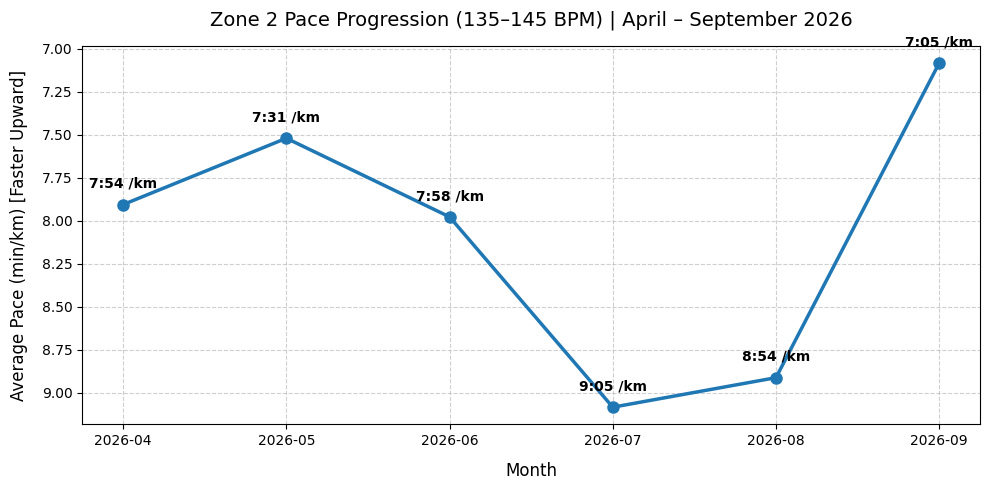

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

# Plot line chart
plt.plot(monthly_z2['Month_Str'], monthly_z2['mean'], marker='o', color='#1f77b4', linewidth=2.5, markersize=8)

# Invert Y-axis so faster pace (lower mm:ss) is visually higher on the chart
plt.gca().invert_yaxis()

# Annotate each point with formatted pace string
for idx, row in monthly_z2.iterrows():
    plt.annotate(
        f"{row['Pace_Formatted']} /km",
        (row['Month_Str'], row['mean']),
        textcoords="offset points",
        xytext=(0, 12),
        ha='center',
        fontweight='bold'
    )

# Formatting
plt.title('Zone 2 Pace Progression (135–145 BPM) | April – September 2026', fontsize=14, pad=15)
plt.xlabel('Month', fontsize=12, labelpad=10)
plt.ylabel('Average Pace (min/km) [Faster Upward]', fontsize=12, labelpad=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Save figure locally in Colab
plt.savefig('zone2_progression.png', dpi=300)
plt.show()